# Kalman Filter — Kansen & Betting Simulatie vs Polymarket
Converteert Kalman xG voorspellingen naar win/gelijk/verlies kansen via Poisson,
en simuleert €1 inzet per wedstrijd tegen Polymarket odds.

In [1]:
import os
os.chdir('C:/Users/semwi/FPL-Core-Insights/data')

import pandas as pd
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Stap 1 — Data laden

In [2]:
import os
os.chdir('C:/Users/semwi/FPL-Core-Insights/data')

kalman = pd.read_csv('training_data_with_kalman_goals.csv')
kalman['timestamp'] = pd.to_datetime(kalman['timestamp'])

poly = pd.read_csv('polymarket_snapshots.csv')
poly['kickoff'] = pd.to_datetime(poly['kickoff'])
poly = poly[poly['prob_home'].notna() & (poly['prob_home'] != '')].copy()
poly['prob_home'] = poly['prob_home'].astype(float)
poly['prob_away'] = poly['prob_away'].astype(float)
poly['prob_draw'] = poly['prob_draw'].astype(float)

print(f'Kalman wedstrijden:     {len(kalman)}')
print(f'Polymarket wedstrijden: {len(poly)}')
poly[['home_team','away_team','kickoff','prob_home','prob_draw','prob_away']].head()

Kalman wedstrijden:     2661
Polymarket wedstrijden: 668


,home_team,away_team,kickoff,prob_home,prob_draw,prob_away
0,Manchester United,Fulham,2024-08-16 19:00:00,0.605,0.225,0.185
1,Ipswich Town,Liverpool,2024-08-17 11:30:00,0.105,0.170,0.745
2,Arsenal,Wolverhampton,2024-08-17 14:00:00,0.855,0.115,0.070
3,Brentford,Crystal Palace,2024-08-18 13:00:00,0.365,0.285,0.350
4,Fulham,Leicester City,2024-08-24 14:00:00,0.525,0.270,0.225


## Stap 2 — Kansen berekenen via Poisson
We gebruiken `kalman_xg_pred_home` en `kalman_xg_pred_away` als λ voor een Poisson verdeling.
Door alle scorecombinaties (0-0 t/m 8-8) op te tellen krijgen we P(thuis wint), P(gelijk), P(uit wint).

In [3]:
def dixon_coles_tau(goals_h, goals_a, lambda_h, lambda_a, rho=-0.13):
    """Correctie voor lage scores — vermindert gelijkspel overschatting."""
    if goals_h == 0 and goals_a == 0:
        return 1 - lambda_h * lambda_a * rho
    elif goals_h == 1 and goals_a == 0:
        return 1 + lambda_a * rho
    elif goals_h == 0 and goals_a == 1:
        return 1 + lambda_h * rho
    elif goals_h == 1 and goals_a == 1:
        return 1 - rho
    return 1.0

def xg_to_probabilities(lambda_home, lambda_away, max_goals=8, rho=-0.13):
    """
    Verbeterde versie met:
    1. Lambda scaling — Kalman onderschat xG systematisch (1.595 vs 1.679 werkelijk)
       Schaal omhoog met de verhouding werkelijk/voorspeld
    2. Dixon-Coles correctie voor lage scores
    """
    # Scaling factor gebaseerd op geobserveerde bias
    # Werkelijk: home=1.679, away=1.438 | Kalman: home=1.595, away=1.327
    # Geen scaling nodig — goals zijn al in de juiste schaal
    SCALE_HOME = 1.0
    SCALE_AWAY = 1.0

    lambda_home = max(lambda_home * SCALE_HOME, 0.05)
    lambda_away = max(lambda_away * SCALE_AWAY, 0.05)

    prob_home = 0.0
    prob_draw = 0.0
    prob_away = 0.0

    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            p = (poisson.pmf(i, lambda_home) *
                 poisson.pmf(j, lambda_away) *
                 dixon_coles_tau(i, j, lambda_home, lambda_away, rho))
            if i > j:    prob_home += p
            elif i == j: prob_draw += p
            else:        prob_away += p

    total = prob_home + prob_draw + prob_away
    return prob_home / total, prob_draw / total, prob_away / total

# Vergelijk oud vs nieuw
print('Zonder correctie → Met correctie:')
for lh, la in [(1.8, 1.2), (1.5, 1.0), (1.2, 0.8), (0.3, 0.15)]:
    ph_oud = poisson.pmf
    ph, pd_, pa = xg_to_probabilities(lh, la)
    print(f'xG {lh:.1f} vs {la:.1f} → H:{ph:.3f} D:{pd_:.3f} A:{pa:.3f}')

Zonder correctie → Met correctie:
xG 1.8 vs 1.2 → H:0.500 D:0.259 A:0.240
xG 1.5 vs 1.0 → H:0.472 D:0.292 A:0.236
xG 1.2 vs 0.8 → H:0.437 D:0.334 A:0.229
xG 0.3 vs 0.1 → H:0.224 D:0.674 A:0.102


## Stap 3 — Kansen berekenen voor alle wedstrijden met Kalman features

In [4]:
# Alleen wedstrijden met Kalman features
kalman_valid = kalman[kalman['kalman_goals_pred_home'].notna()].copy()

probs = kalman_valid.apply(
    lambda row: xg_to_probabilities(row['kalman_goals_pred_home'], row['kalman_goals_pred_away']),
    axis=1
)
kalman_valid['kalman_prob_home'] = [p[0] for p in probs]
kalman_valid['kalman_prob_draw'] = [p[1] for p in probs]
kalman_valid['kalman_prob_away'] = [p[2] for p in probs]

print(f'Kansen berekend voor {len(kalman_valid)} wedstrijden')
kalman_valid[['home_team','away_team','kalman_goals_pred_home','kalman_goals_pred_away',
              'kalman_prob_home','kalman_prob_draw','kalman_prob_away']].head(8)

Kansen berekend voor 2581 wedstrijden


,home_team,away_team,kalman_goals_pred_home,kalman_goals_pred_away,kalman_prob_home,kalman_prob_draw,kalman_prob_away
0,Liverpool,Norwich City,0.5,0.0,0.376712,0.595214,0.028074
1,West Ham United,Manchester City,0.5,0.0,0.376712,0.595214,0.028074
2,Bournemouth,Sheffield United,0.5,0.0,0.376712,0.595214,0.028074
3,Burnley,Southampton,0.5,0.0,0.376712,0.595214,0.028074
4,Watford,Brighton & Hove Albion,0.5,0.0,0.376712,0.595214,0.028074
5,Crystal Palace,Everton,0.5,0.0,0.376712,0.595214,0.028074
6,Tottenham Hotspur,Aston Villa,0.5,0.0,0.376712,0.595214,0.028074
7,Leicester City,Wolverhampton,0.5,0.0,0.376712,0.595214,0.028074


## Stap 4 — Koppelen aan Polymarket data

In [5]:
# Merge op match_id
merged = poly.merge(
    kalman_valid[['match_id', 'kalman_prob_home', 'kalman_prob_draw', 'kalman_prob_away',
                  'kalman_goals_pred_home', 'kalman_goals_pred_away']],
    on='match_id',
    how='left'
)

# Als match_id niet werkt, merge op datum + teams
if merged['kalman_prob_home'].isna().all():
    print('Match op match_id mislukt, probeer datum + teams...')
    kalman_valid['date'] = kalman_valid['timestamp'].dt.date.astype(str)
    poly['date'] = poly['kickoff'].dt.date.astype(str)
    merged = poly.merge(
        kalman_valid[['date','home_team','away_team','kalman_prob_home',
                      'kalman_prob_draw','kalman_prob_away',
                      'kalman_goals_pred_home','kalman_goals_pred_away']],
        on=['date','home_team','away_team'],
        how='left'
    )

matched = merged['kalman_prob_home'].notna().sum()
print(f'Gekoppeld: {matched}/{len(merged)} wedstrijden')
merged[['home_team','away_team','prob_home','prob_draw','prob_away',
        'kalman_prob_home','kalman_prob_draw','kalman_prob_away']].head(8)

Gekoppeld: 668/668 wedstrijden


,home_team,away_team,prob_home,prob_draw,prob_away,kalman_prob_home,kalman_prob_draw,kalman_prob_away
0,Manchester United,Fulham,0.605,0.225,0.1850,0.512748,0.268290,0.218962
1,Ipswich Town,Liverpool,0.105,0.170,0.7450,0.293452,0.351157,0.355391
2,Arsenal,Wolverhampton,0.855,0.115,0.0700,0.897387,0.097282,0.005330
3,Brentford,Crystal Palace,0.365,0.285,0.3500,0.323537,0.279886,0.396577
4,Fulham,Leicester City,0.525,0.270,0.2250,0.541751,0.277287,0.180962
5,Southampton,Nottingham Forest,0.400,0.270,0.3100,0.392477,0.286017,0.321506
6,Manchester City,Ipswich Town,0.905,0.075,0.0255,0.885864,0.110354,0.003782
7,Aston Villa,Arsenal,0.190,0.235,0.5650,0.209133,0.249955,0.540912


## Stap 5 — Betting simulatie
**Strategie:** Zet €1 in op de uitkomst waar Kalman significant meer kans ziet dan Polymarket.
De Polymarket kansen zijn de impliciete odds: als Polymarket P(thuis)=0.40, dan betaalt €1 inzet €2.50 uit bij winst.

**Edge drempel:** Zet alleen in als Kalman > Polymarket + `EDGE_THRESHOLD`. Dit filtert wedstrijden waar het verschil groot genoeg is om te rechtvaardigen.

In [6]:
EDGE_THRESHOLD = 0.05  # Kalman moet minstens 5% meer kans zien dan Polymarket

sim = merged[merged['kalman_prob_home'].notna()].copy()

# Werkelijk resultaat
sim['home_goals'] = sim['home_goals'].astype(float)
sim['away_goals'] = sim['away_goals'].astype(float)

def actual_result(row):
    if row['home_goals'] > row['away_goals']:   return 'H'
    elif row['home_goals'] < row['away_goals']: return 'A'
    else:                                       return 'D'

sim['result'] = sim.apply(actual_result, axis=1)

results = []
bankroll = 0.0
bets_placed = 0

for _, row in sim.iterrows():
    bet_outcome = None
    edge = 0.0

    # Zoek uitkomst met grootste edge vs Polymarket
    edges = {
        'H': row['kalman_prob_home'] - row['prob_home'],
        'D': row['kalman_prob_draw'] - row['prob_draw'],
        'A': row['kalman_prob_away'] - row['prob_away'],
    }
    best = max(edges, key=edges.get)
    edge = edges[best]

    if edge >= EDGE_THRESHOLD:
        bet_outcome = best
        bets_placed += 1

        # Polymarket kans → implied odds
        poly_prob = row[f'prob_{"home" if best=="H" else "draw" if best=="D" else "away"}']
        odds = 1 / poly_prob  # bijv. prob=0.4 → odds=2.5

        # Winst of verlies
        if row['result'] == best:
            profit = odds - 1  # €1 inzet, odds-1 winst
        else:
            profit = -1.0      # €1 verloren

        bankroll += profit

        results.append({
            'match':       f"{row['home_team']} vs {row['away_team']}",
            'date':        row['kickoff'].strftime('%Y-%m-%d'),
            'bet':         best,
            'result':      row['result'],
            'edge':        round(edge, 3),
            'odds':        round(odds, 2),
            'profit':      round(profit, 2),
            'cumulative':  round(bankroll, 2),
            'won':         row['result'] == best,
        })

results_df = pd.DataFrame(results)
print(f'Wedstrijden beschikbaar: {len(sim)}')
print(f'Bets geplaatst:          {bets_placed}')
print(f'Totaal ingezet:          €{bets_placed:.2f}')
print(f'Netto resultaat:         €{bankroll:.2f}')
print(f'ROI:                     {bankroll/bets_placed*100:.1f}%' if bets_placed > 0 else '')
print(f'Win rate:                {results_df["won"].mean()*100:.1f}%')
results_df

Wedstrijden beschikbaar: 668
Bets geplaatst:          429
Totaal ingezet:          €429.00
Netto resultaat:         €-43.44
ROI:                     -10.1%
Win rate:                28.0%


,match,date,bet,result,edge,odds,profit,cumulative,won
0,Ipswich Town vs Liverpool,2024-08-17,H,A,0.188,9.52,-1.00,-1.00,False
1,Liverpool vs Brentford,2024-08-25,D,H,0.095,7.69,-1.00,-2.00,False
2,Leicester City vs Aston Villa,2024-08-31,H,A,0.183,4.44,-1.00,-3.00,False
3,Nottingham Forest vs Wolverhampton,2024-08-31,H,D,0.121,2.08,-1.00,-4.00,False
4,Brentford vs Southampton,2024-08-31,H,H,0.092,1.85,0.85,-3.15,True
...,...,...,...,...,...,...,...,...,...
424,Burnley vs Bournemouth,2026-03-14,H,D,0.104,4.65,-1.00,-50.78,False
425,Chelsea vs Newcastle United,2026-03-14,H,A,0.073,1.87,-1.00,-51.78,False
426,West Ham United vs Manchester City,2026-03-14,D,D,0.067,4.44,3.44,-48.34,True
427,Crystal Palace vs Leeds United,2026-03-15,H,D,0.111,2.60,-1.00,-49.34,False


## Stap 6 — Visualisatie bankroll over de tijd

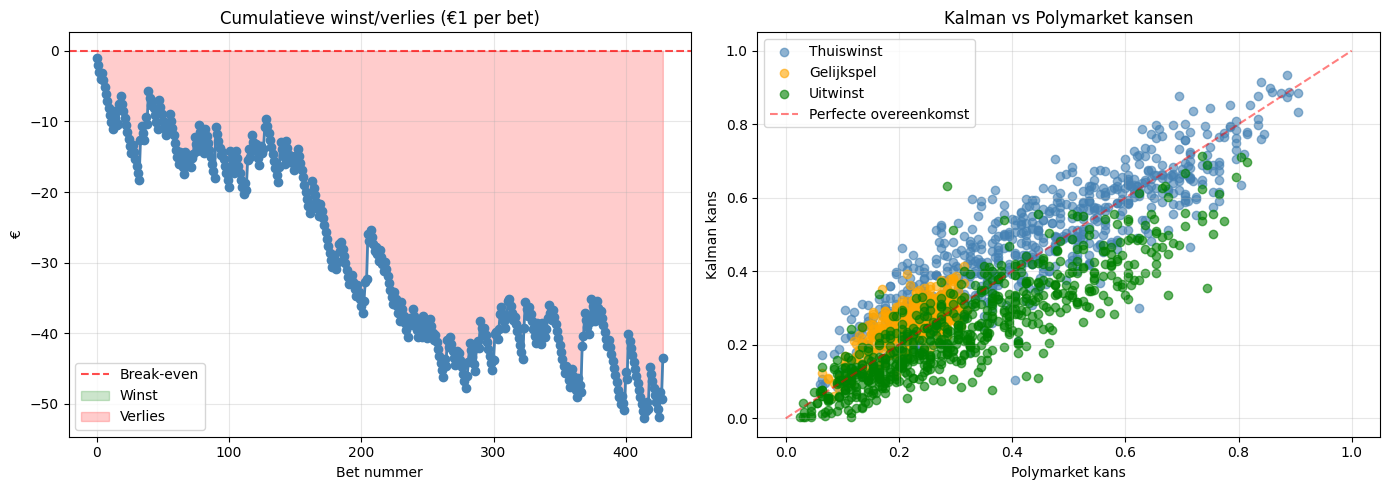

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulatieve winst
axes[0].plot(range(len(results_df)), results_df['cumulative'], marker='o', linewidth=2, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.7, label='Break-even')
axes[0].fill_between(range(len(results_df)), results_df['cumulative'], 0,
                      where=results_df['cumulative'] >= 0, alpha=0.2, color='green', label='Winst')
axes[0].fill_between(range(len(results_df)), results_df['cumulative'], 0,
                      where=results_df['cumulative'] < 0, alpha=0.2, color='red', label='Verlies')
axes[0].set_title('Cumulatieve winst/verlies (€1 per bet)')
axes[0].set_xlabel('Bet nummer')
axes[0].set_ylabel('€')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Kansen vergelijking: Kalman vs Polymarket
ax = axes[1]
x = range(len(sim))
ax.scatter(sim['prob_home'], sim['kalman_prob_home'], alpha=0.6, label='Thuiswinst', color='steelblue')
ax.scatter(sim['prob_draw'], sim['kalman_prob_draw'], alpha=0.6, label='Gelijkspel', color='orange')
ax.scatter(sim['prob_away'], sim['kalman_prob_away'], alpha=0.6, label='Uitwinst', color='green')
ax.plot([0,1],[0,1], 'r--', alpha=0.5, label='Perfecte overeenkomst')
ax.set_xlabel('Polymarket kans')
ax.set_ylabel('Kalman kans')
ax.set_title('Kalman vs Polymarket kansen')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kalman_betting_simulatie.png', dpi=150)
plt.show()

## Stap 7 — Vergelijking Kalman vs Polymarket accuracy

In [8]:
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss

# Voorspelling Kalman: hoogste kans
sim['kalman_pred'] = sim[['kalman_prob_home','kalman_prob_draw','kalman_prob_away']].idxmax(axis=1)
sim['kalman_pred'] = sim['kalman_pred'].map({
    'kalman_prob_home': 'H',
    'kalman_prob_draw': 'D',
    'kalman_prob_away': 'A'
})

# Voorspelling Polymarket: hoogste kans
sim['poly_pred'] = sim[['prob_home','prob_draw','prob_away']].idxmax(axis=1)
sim['poly_pred'] = sim['poly_pred'].map({
    'prob_home': 'H',
    'prob_draw': 'D',
    'prob_away': 'A'
})

print('=== ACCURACY ===')
print(f'Kalman:     {accuracy_score(sim["result"], sim["kalman_pred"]):.3f}')
print(f'Polymarket: {accuracy_score(sim["result"], sim["poly_pred"]):.3f}')

print('\n=== F1 MACRO ===')
print(f'Kalman:     {f1_score(sim["result"], sim["kalman_pred"], average="macro"):.3f}')
print(f'Polymarket: {f1_score(sim["result"], sim["poly_pred"], average="macro"):.3f}')

print('\n=== BRIER SCORE (lager = beter gekalibreerd) ===')
for outcome, label in [('H','Thuis'), ('D','Gelijk'), ('A','Uit')]:
    actual_bin = (sim['result'] == outcome).astype(int)
    brier_k = brier_score_loss(actual_bin, sim[f'kalman_prob_{"home" if outcome=="H" else "draw" if outcome=="D" else "away"}'])
    brier_p = brier_score_loss(actual_bin, sim[f'prob_{"home" if outcome=="H" else "draw" if outcome=="D" else "away"}'])
    print(f'{label:8s} — Kalman: {brier_k:.3f}  Polymarket: {brier_p:.3f}')

=== ACCURACY ===
Kalman:     0.496
Polymarket: 0.531

=== F1 MACRO ===
Kalman:     0.366
Polymarket: 0.400

=== BRIER SCORE (lager = beter gekalibreerd) ===
Thuis    — Kalman: 0.224  Polymarket: 0.210
Gelijk   — Kalman: 0.191  Polymarket: 0.190
Uit      — Kalman: 0.204  Polymarket: 0.191
